In [4]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt

In [5]:
bids_folder_subjects = '/mnt_03/ds-dnumrisk' 
bids_folder_matrices = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
target_dir = op.join(bids_folder_matrices,'derivatives','gradients')
os.makedirs(target_dir, exist_ok=True)

subList = [f[4:6] for f in os.listdir(bids_folder_subjects) if f[0:4] == 'sub-' and len(f) == 6]

# group list
#df_participants = pd.read_csv(op.join(bids_folder_subjects, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
#group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')

source_folder = op.join(bids_folder_matrices,'derivatives','correlation_matrices')
target_folder = op.join(bids_folder_matrices,'derivatives','gradients')

specification = '' # align_spec = '_align-procrustes'
ses = 1

In [7]:
print(subList)

['21', '59', '54', '15', '52', '08', '57', '50', '36', '56', '02', '22', '01', '19', '23', '06', '18', '13', '03', '31', '55', '41', '65', '49', '29', '34', '17', '27', '30', '51', '20', '66', '24', '46', '39', '47', '14', '37', '04', '61', '45', '26', '58', '33', '40', '64', '32', '11', '35', '16', '38', '48', '63', '43', '10', '53', '05', '07', '09', '12', '62', '28', '42', '25', '44', '60']


In [6]:
from my_utils import get_basic_mask

mask, labeling_noParcel = get_basic_mask()
N_vertices = len(np.where(mask==True)[0])

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


In [ ]:
# Compute average correlation matrix for all subjects for each stimulus type
group = 'All'

stimuli_types = ['stimulus_1', 'stimulus_2', 'remaining']

for stimulus in stimuli_types:
    print(f'Processing {stimulus}...')
    
    # Initialize zero matrix for averaging
    matrix_zeros = np.zeros((N_vertices, N_vertices))
    av_cm = matrix_zeros.copy()

    for sub in subList:
        try:
            # Load the correlation matrix for the current stimulus type
            correlation_matrix = np.load(op.join(
                source_folder,
                f'sub-{sub}_ses-{ses}_unfiltered_{stimulus}_space-fsav5.npy'
            ))
            av_cm += np.arctan(correlation_matrix)  # Fisher Z-transformation
            print(f'Subject {sub} added for {stimulus}')
        except Exception as e:
            print(f'Subject {sub} failed for {stimulus}: {e}')

    # Compute the average correlation matrix
    av_cm = av_cm / len(subList)
    av_cm_transf = np.tan(av_cm)  # Sanity check: diagonal should be 1!

    # Save the average correlation matrix for the current stimulus type
    np.save(op.join(source_folder,f'cm_av_ses-{ses}_fsav5_unfiltered_{stimulus}.npy'), av_cm_transf)
    print(f'Average correlation matrix saved for {stimulus}')

Processing stimulus_1...
Subject 21 added for stimulus_1
Subject 59 added for stimulus_1
Subject 54 added for stimulus_1
Subject 15 added for stimulus_1
Subject 52 added for stimulus_1
Subject 08 added for stimulus_1
Subject 57 added for stimulus_1
Subject 50 added for stimulus_1
Subject 36 added for stimulus_1
Subject 56 added for stimulus_1
Subject 02 added for stimulus_1
Subject 22 added for stimulus_1
Subject 01 added for stimulus_1
Subject 19 added for stimulus_1


Shape: (18715, 18715)
Type: <class 'numpy.ndarray'>
[[ 1.00000004e+00 -9.33470571e-04  7.79653138e-02 ...  8.83833577e-03
   3.94405580e-03 -2.79485956e-03]
 [-9.33470345e-04  1.00000004e+00 -1.59014720e-02 ... -2.45609133e-02
  -2.07556398e-02 -2.45402720e-02]
 [ 7.79653137e-02 -1.59014719e-02  1.00000004e+00 ...  1.26435459e-02
   1.21507842e-02  1.39490279e-02]
 ...
 [ 8.83833577e-03 -2.45609132e-02  1.26435460e-02 ...  1.00000004e+00
   3.18106181e-01  1.14743716e-01]
 [ 3.94405580e-03 -2.07556399e-02  1.21507843e-02 ...  3.18106181e-01
   1.00000004e+00  3.52376387e-01]
 [-2.79485956e-03 -2.45402720e-02  1.39490280e-02 ...  1.14743716e-01
   3.52376387e-01  1.00000004e+00]]


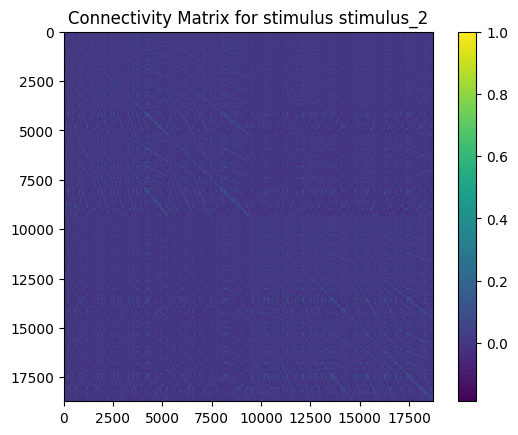

In [8]:
import numpy as np
import os.path as op
import matplotlib.pyplot as plt

# Example subject and stimulus
stimulus = 'stimulus_2'

# File path
file_path = op.join(source_folder, f'cm_av_ses-{ses}_fsav5_unfiltered_{stimulus}.npy')

# Load the connectivity matrix
connectivity_matrix = np.load(file_path, allow_pickle=True)

# Print basic information
print(f"Shape: {connectivity_matrix.shape}")
print(f"Type: {type(connectivity_matrix)}")
print(connectivity_matrix)

# Visualize the matrix
plt.imshow(connectivity_matrix, cmap='viridis')
plt.colorbar()
plt.title(f'Connectivity Matrix for stimulus {stimulus}')
plt.show()

In [ ]:
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
from my_utils import get_basic_mask

mask, labeling_noParcel = get_basic_mask()

sub = 'All'
stimulus = 'stimulus_1'

n_components = 10 # reference gradient only has 3 components anyway... for better alignment one needs more components?! (according to Alam, 2022, L-R GM differences & cognition )

av_cm = np.load(op.join(source_folder,f'cm_av_ses-{ses}_fsav5_unfiltered_{stimulus}.npy'))

target_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients', f'sub-{sub}', f'stimulus_{stimulus}')
if not op.exists(target_dir):
    os.makedirs(target_dir)

# load in reference gradient and apply same filter
g_ref = np.load(op.join(bids_folder_subjects,'derivatives', 'gradients','sub-All/sub-All_gradients_N-10.npy')) # same labeling_noParcel as cm_unfiltered
g_ref = g_ref[:, mask] #

# now perform embedding on cleaned data + alignment
print(f'start fitting gradintes now')
gm = GradientMaps(n_components=n_components, alignment='procrustes') # defaults: approacch = 'dm', kernel = None
gm.fit(av_cm,reference=g_ref)
print(f'finished stimulus_{stimulus}: gradients generated')

np.save(op.join(target_dir,f'sub-{sub}_lambdas_space-fsaverag5_n10{specification}_stimulus_{stimulus}.npy'), gm.lambdas_) # save all together
gm_= gm.gradients_.T 
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_gradients_space-fsaverag5_n10{specification}_stimulus_{stimulus}.npy'), grad) # save all together
gm_ = gm.aligned_.T
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_g-aligned_space-fsaverag5_n10{specification}_stimulus_{stimulus}.npy'), grad) # save all together 


In [19]:
g_ref.shape

(10, 18715)

In [24]:
gm.fit(av_cm,reference=g_ref.T)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/brainspace-0.1.4-py3.10.egg/brainspace/gradient/embedding.py:70: UserWarning: Affinity is not symmetric. Making symmetric.
  warnings.warn('Affinity is not symmetric. Making symmetric.')


GradientMaps(alignment='procrustes')

In [13]:
sub = 'All'
stimulus = 'stimulus_1'
spec = 'gradients'  #g-aligned
target_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients', f'sub-{sub}', f'stimulus_{stimulus}')

grad = np.load(op.join(target_dir,f'sub-{sub}_{spec}_space-fsaverag5_n10{specification}_stimulus_{stimulus}.npy'))


Text(0.5, 0.9, 'stimulus_1 - gradients')

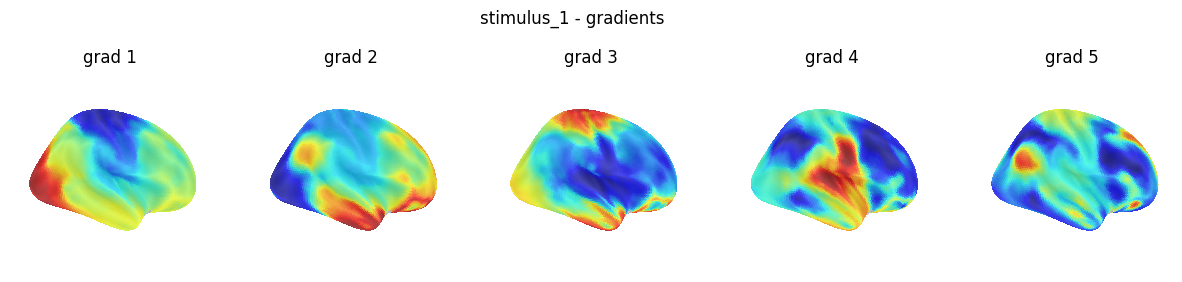

In [14]:
# plotting gradients

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from  nilearn.datasets import fetch_surf_fsaverage
fsaverage = fetch_surf_fsaverage() # default 5

side_view = 'medial'
cmap = 'jet'
n_comp = 5

figure, axes = plt.subplots(nrows=1, ncols=n_comp,figsize = (15,4), subplot_kw=dict(projection='3d'))
for i in range(0,n_comp):
    gm = np.split(grad[i],2) # for i, hemi in enumerate([‘L’, ‘R’]): --> left first
    gm_r = gm[1]
    nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right
                view= side_view,cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
                bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7 ,axes=axes[i]) #
    axes[i].set(title=f'grad {i+1}')
figure.suptitle(f'{stimulus} - {spec}', y=0.9)

In [23]:
# plot lambdas

from kneed import KneeLocator #  knee point is the point of maximum curvature.

sub = 'All'
n_comp=10
stimuli_types = ['stimulus_1', 'stimulus_2', 'remaining']

# Loop through each stimulus
for stimulus in stimuli_types:
    print(f"Processing {stimulus}...")

    fn_lambdas = op.join(bids_folder_matrices, 'derivatives', 'gradients', f'sub-{sub}', f'stimulus_{stimulus}',f'sub-{sub}_lambdas_space-fsaverag5_n10{specification}_stimulus_{stimulus}.npy')
    lambdas = np.load(fn_lambdas)
    
    # Find the knee point
    kneedle = KneeLocator(x=range(1, len(lambdas) + 1), y=lambdas, S=1.0, curve="convex", direction="decreasing")
    
    # Plot the knee
    plt.figure()
    kneedle.plot_knee()
    plt.title(f"Knee Plot for {stimulus}")
    plt.xlabel("Component")
    plt.ylabel("Lambda")

    # Save the plot
    output_plot_path = op.join(bids_folder_matrices, 'derivatives', 'gradients', f'sub-{sub}', f'stimulus_{stimulus}', f'sub-{sub}_knee_plot_{stimulus}.png')
    plt.savefig(output_plot_path)
    plt.close()
    print(f"Saved knee plot for {stimulus} at {output_plot_path}")


Processing stimulus_1...
Saved knee plot for stimulus_1 at /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients/sub-All/stimulus_stimulus_1/sub-All_knee_plot_stimulus_1.png
Processing stimulus_2...
Saved knee plot for stimulus_2 at /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients/sub-All/stimulus_stimulus_2/sub-All_knee_plot_stimulus_2.png
Processing remaining...
Saved knee plot for remaining at /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients/sub-All/stimulus_remaining/sub-All_knee_plot_remaining.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

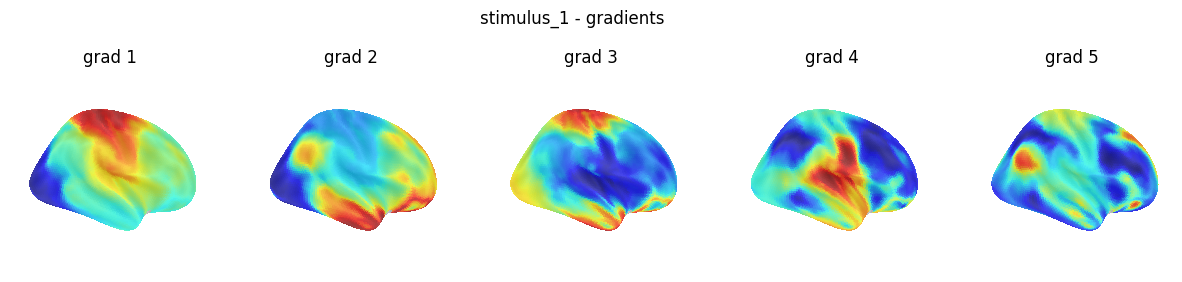

In [ ]:
# code to flip grad 1 for stim_1 

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from nilearn.datasets import fetch_surf_fsaverage

fsaverage = fetch_surf_fsaverage()  # default fsaverage5

side_view = 'medial'
cmap = 'jet'
n_comp = 5

figure, axes = plt.subplots(nrows=1, ncols=n_comp, figsize=(15, 4), subplot_kw=dict(projection='3d'))
for i in range(0, n_comp):
    # Flip grad 1 values if i == 0
    grad_to_plot = -grad[i] if i == 0 else grad[i]
    
    # Split into left and right hemispheres
    gm = np.split(grad_to_plot, 2)  # Left first, then right
    gm_r = gm[1]
    
    # Plot the right hemisphere
    nplt.plot_surf(
        surf_mesh=fsaverage.infl_right, surf_map=gm_r,  # infl_right or pial_right
        view=side_view, cmap=cmap, colorbar=False,
        bg_map=fsaverage.sulc_right, bg_on_data=True, darkness=0.7, axes=axes[i]
    )
    axes[i].set(title=f'grad {i+1}')

figure.suptitle(f'{stimulus} - {spec}', y=0.9)
plt.show()

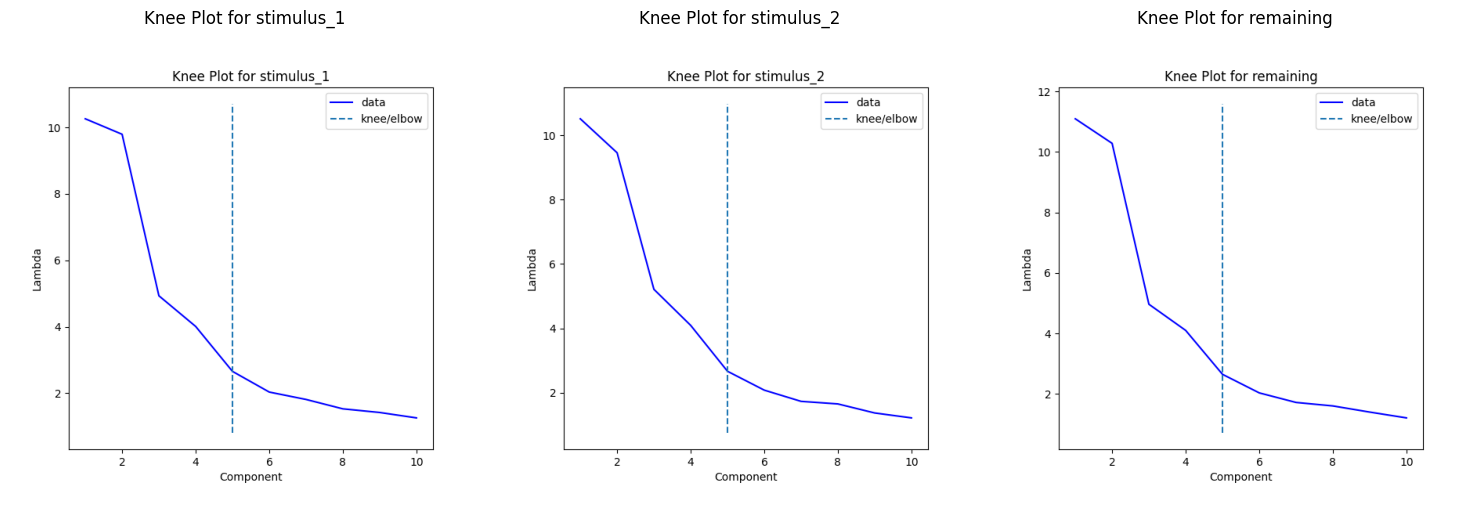

In [ ]:
import matplotlib.pyplot as plt
import os.path as op

# Parameters
sub = 'All'
stimuli_types = ['stimulus_1', 'stimulus_2', 'remaining']

# Initialize figure for side-by-side visualization
fig, axes = plt.subplots(1, len(stimuli_types), figsize=(15, 5))  # 1 row, 3 columns

# Loop through each stimulus to load and display the saved plots
for i, stimulus in enumerate(stimuli_types):
    # File path to the saved plot
    plot_path = op.join(bids_folder_matrices, 'derivatives', 'gradients', f'sub-{sub}', f'stimulus_{stimulus}', f'sub-{sub}_knee_plot_{stimulus}.png')
    
    # Load and display the saved plot
    img = plt.imread(plot_path)
    ax = axes[i]
    ax.imshow(img)
    ax.axis('off')  # Turn off axes for better visualization
    ax.set_title(f"Knee Plot for {stimulus}")

# Adjust layout and show the combined visualization
plt.tight_layout()
plt.show()

Processing comparison: stimulus_1 vs stimulus_2...
Correlation Matrix for stimulus_1 vs stimulus_2:
[[9.91681831e-01 4.25743366e-04 2.27470137e-02 6.60588933e-03
  1.73570863e-02]
 [8.57685812e-04 9.98043493e-01 4.25069185e-02 1.92683156e-03
  8.31368925e-03]
 [2.58966265e-02 4.42633536e-02 9.96845012e-01 2.83194076e-02
  1.66314556e-02]
 [2.46942734e-03 2.43407324e-03 2.79718223e-02 9.88226211e-01
  6.44309533e-03]
 [1.76048827e-02 8.19617546e-03 1.66344653e-02 8.39487223e-03
  9.93751623e-01]]


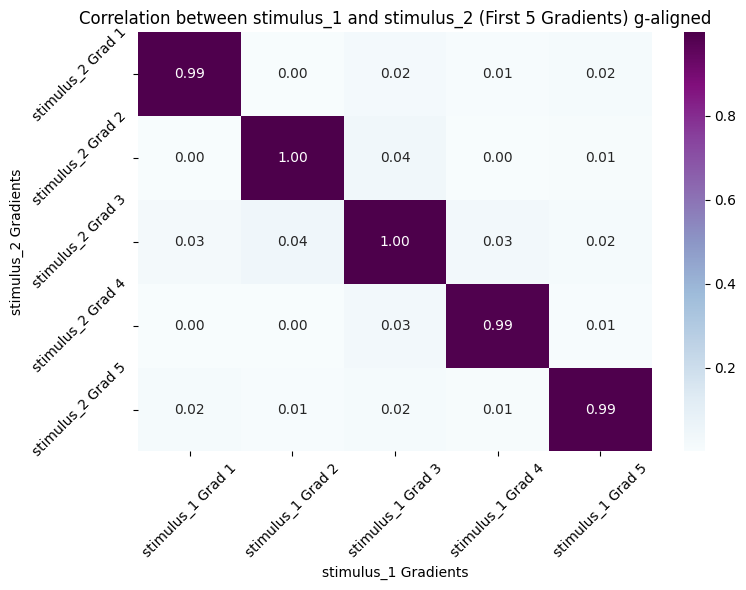

Processing comparison: stimulus_1 vs remaining...
Correlation Matrix for stimulus_1 vs remaining:
[[9.96516285e-01 1.76255447e-02 1.50921600e-02 7.03716705e-02
  6.69003799e-03]
 [1.77240573e-02 9.98008435e-01 1.56398489e-02 5.66857993e-03
  1.65516683e-03]
 [1.46126502e-02 1.46009641e-02 9.97968710e-01 1.68788270e-02
  1.43867591e-02]
 [6.79158109e-02 5.08383229e-03 1.64623632e-02 9.95480315e-01
  8.40408935e-03]
 [6.33233079e-03 6.84211157e-04 1.39693479e-02 8.41334073e-03
  9.93006693e-01]]


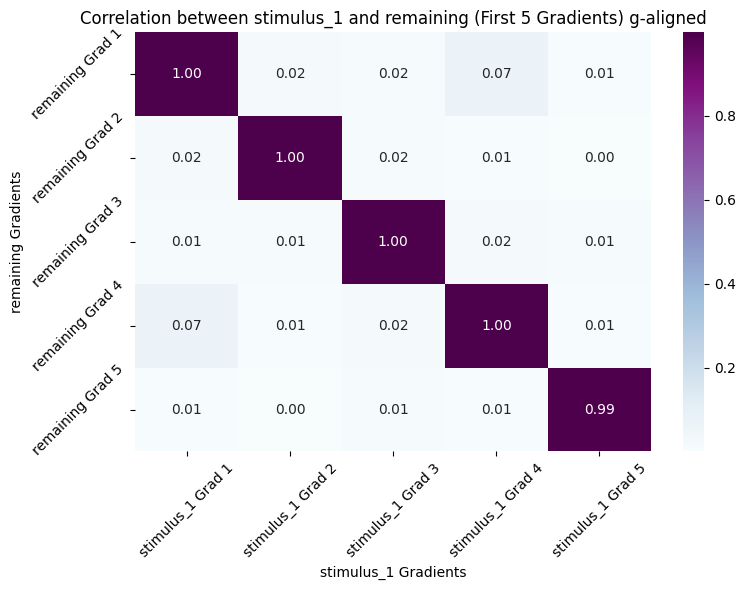

Processing comparison: stimulus_2 vs remaining...
Correlation Matrix for stimulus_2 vs remaining:
[[0.99556204 0.02768916 0.0223382  0.04494595 0.01198814]
 [0.02655449 0.99775353 0.04522913 0.017505   0.02013808]
 [0.02011891 0.04215345 0.99700693 0.01661363 0.0077494 ]
 [0.04305876 0.01931273 0.01709319 0.99423406 0.00679638]
 [0.01291341 0.0168403  0.00892636 0.007082   0.99469455]]


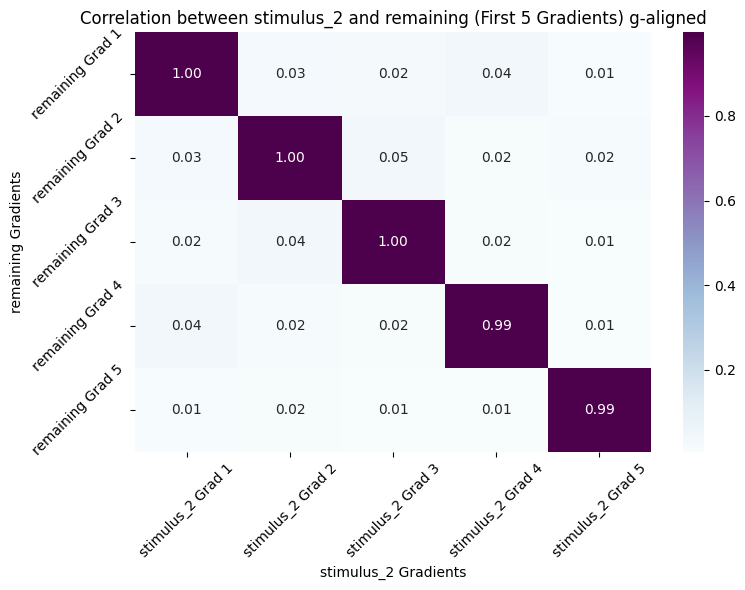

In [10]:
# plot correlation matrix checking similarity between stim 1 and stim 2, stim 1 and remaining, stim 2 and remaining

from neuromaps.stats import compare_images
import numpy as np
import os.path as op
import seaborn as sns
import matplotlib.pyplot as plt

# Parameters
sub = 'All'
spec = 'g-aligned'  # gradients
stimuli_pairs = [
    ('stimulus_1', 'stimulus_2'),
    ('stimulus_1', 'remaining'),
    ('stimulus_2', 'remaining')
]

n_gradients_to_compare = 5  # Compare only the first 5 gradients

# Loop over stimulus pairs and calculate correlations
for stim1, stim2 in stimuli_pairs:
    print(f"Processing comparison: {stim1} vs {stim2}...")
    
    # File paths to the gradient files
    grad1_file = op.join(bids_folder_matrices, 'derivatives', 'gradients', f'sub-{sub}', f'stimulus_{stim1}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stim1}.npy')
    grad2_file = op.join(bids_folder_matrices, 'derivatives', 'gradients', f'sub-{sub}', f'stimulus_{stim2}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stim2}.npy')
    
    # Load the gradients
    grad1 = np.load(grad1_file)[:n_gradients_to_compare]  # Load first 5 gradients
    grad2 = np.load(grad2_file)[:n_gradients_to_compare]  # Load first 5 gradients
    
    # Initialize correlation matrix for this pair
    correlation_matrix = np.zeros((n_gradients_to_compare, n_gradients_to_compare))
    
    # Compute correlations between gradients
    for i in range(n_gradients_to_compare):
        for j in range(n_gradients_to_compare):
            corrcoef = compare_images(grad1[i], grad2[j], metric='pearsonr')
            correlation_matrix[i, j] = np.abs(corrcoef)
    
    # Print the correlation matrix
    print(f"Correlation Matrix for {stim1} vs {stim2}:")
    print(correlation_matrix)
    
    # Plot the correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="BuPu",
                xticklabels=[f'{stim1} Grad {i+1}' for i in range(n_gradients_to_compare)],
                yticklabels=[f'{stim2} Grad {i+1}' for i in range(n_gradients_to_compare)])
    plt.title(f"Correlation between {stim1} and {stim2} (First {n_gradients_to_compare} Gradients) {spec}")
    plt.xlabel(f"{stim1} Gradients")
    plt.ylabel(f"{stim2} Gradients")
    
    # Rotate the x-axis labels
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [31]:
print(grad1.shape)


(5, 20484)


In [7]:
from my_utils import get_glasser_parcels, get_glasser_CAatlas_mapping
import os
import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import seaborn as sns

rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
ca_cmap = ListedColormap(np.vstack(([1, 1, 1, 1], rgb)), 'custom_colormap') # add white infront, 0=unknown, 1-12 actual labels

# Update the function to use the correct path
mask_glasser, labeling_glasser = get_glasser_parcels(space='fsaverage5')
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(
    glasser_CAatlas_mapping['ca_network'].values,
    labeling_glasser,
    mask=mask_glasser
)

In [18]:
CAatlas_names['Network Name']

Label Number
1                  Visual1
2                  Visual2
3              Somatomotor
4        Cingulo-Opercular
5         Dorsal-attention
6                 Language
7           Frontoparietal
8                 Auditory
9                  Default
10    Posterior-Multimodal
11      Ventral-Multimodal
12        Orbito-Affective
Name: Network Name, dtype: object

Processing stimulus_1...
Processing stimulus_2...
Processing remaining...


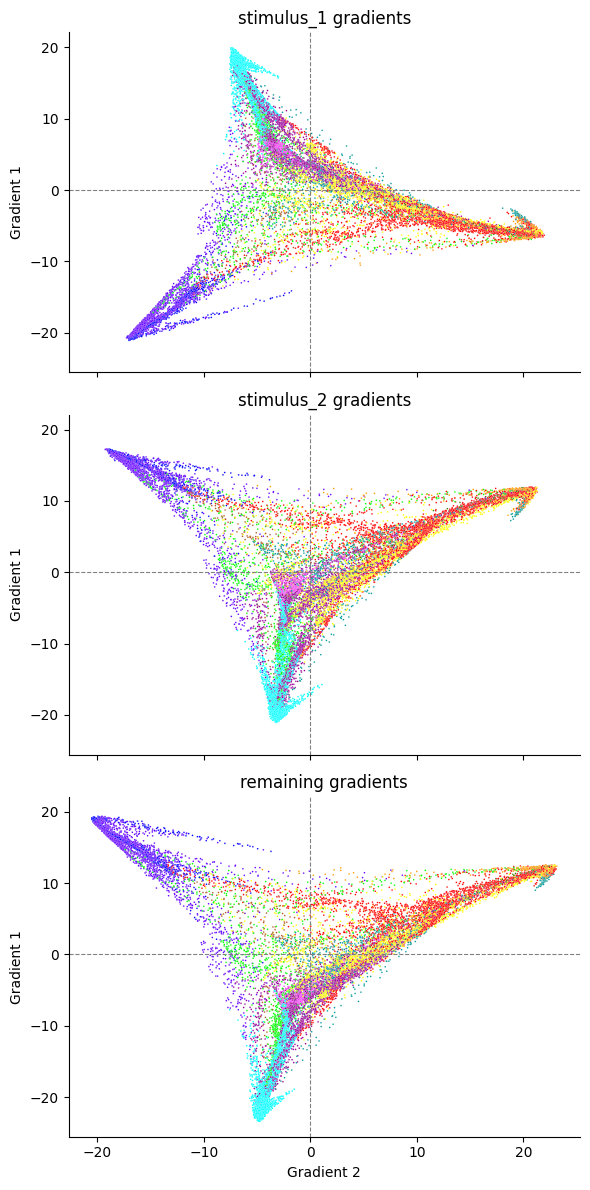

In [ ]:
import numpy as np
import os.path as op
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sub = 'All'
stimuli_types = ['stimulus_1', 'stimulus_2', 'remaining']
spec = 'gradients'  # 'g-aligned'

# Create a dictionary mapping network names to colors
network_colors = {name: color for name, color in zip(CAatlas_names['Network Name'], ca_cmap.colors[1:])}

# Placeholder for results
correlation_results = {}

# Create subplots for each stimulus
fig, axs = plt.subplots(len(stimuli_types), 1, figsize=(6, 12), sharex=True, sharey=True)

for i, stimulus in enumerate(stimuli_types):  # Use enumerate to get the index (i) and stimulus name
    print(f'Processing {stimulus}...')
    
    try:
        # Load the combined gradient matrix for the current stimulus
        gradients = np.load(op.join(bids_folder_matrices, 'derivatives', 'gradients', 
                                     f'sub-{sub}', f'stimulus_{stimulus}', 
                                     f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stimulus}.npy'))

        # Extract the first two rows (Gradient 1 and Gradient 2)
        grad1 = gradients[0, :]  # First row: Gradient 1
        grad2 = gradients[1, :]  # Second row: Gradient 2

        # Create a DataFrame for plotting
        df = pd.DataFrame({
            'Gradient 1': grad1,
            'Gradient 2': grad2,
            'ca_network': caNets_fsav5_mapping  # Map network indices to vertices
        })

        # Map network names to the ca_network column
        df['ca_network_name'] = df['ca_network'].map(CAatlas_names['Network Name'])

        # Scatter plot of Gradient 1 vs Gradient 2
        sns.scatterplot(data=df, x='Gradient 2', y='Gradient 1', hue='ca_network_name', 
                        palette=network_colors, s=1.4, legend=False, ax=axs[i])
        axs[i].set(title=f'{stimulus} {spec}', xlabel='Gradient 2', ylabel='Gradient 1')
        axs[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axs[i].axvline(0, color='gray', linestyle='--', linewidth=0.8)

    except Exception as e:
        print(f'Failed to process {stimulus}: {e}')

# Adjust layout and remove spines
plt.tight_layout()
sns.despine()
plt.show()

In [27]:
df[df['ca_network_name'] == 'Auditory']['Gradient 1']

27       8.812959
28      -0.229075
123      6.250456
125      5.506560
128      6.955718
           ...   
20419    0.893755
20420   -1.040629
20421   -2.818489
20422   -2.000445
20423   -2.028360
Name: Gradient 1, Length: 531, dtype: float64

Processing comparison: stimulus_1 vs reference_grad...
Correlation Matrix for stimulus_1 vs reference_grad:
[[0.94140523 0.3344658  0.02307938 0.068927   0.0046822 ]
 [0.34017492 0.93490369 0.00564678 0.03532913 0.01236503]
 [0.03241174 0.01079821 0.99205781 0.07481061 0.0079248 ]
 [0.08139613 0.02220369 0.09065824 0.99161312 0.03250133]
 [0.02323826 0.01969299 0.00781104 0.02307357 0.99451381]]


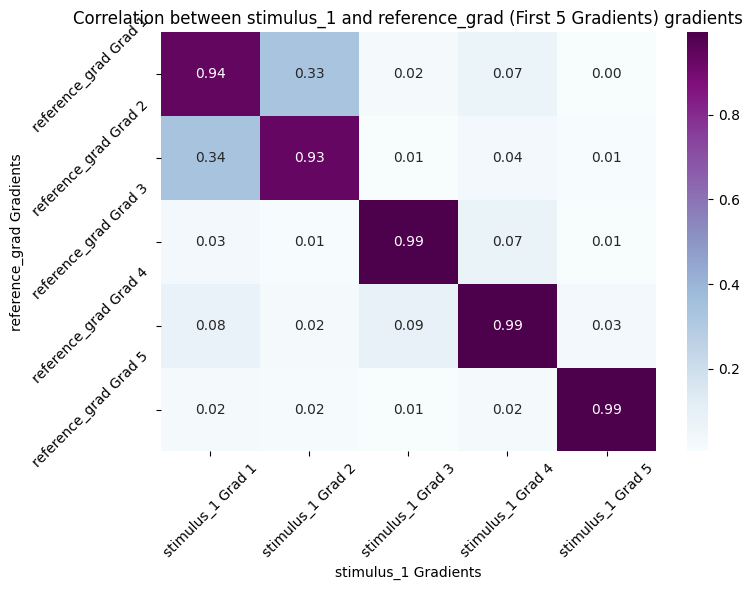

Processing comparison: stimulus_2 vs reference_grad...
Correlation Matrix for stimulus_2 vs reference_grad:
[[0.98591973 0.14880658 0.0426869  0.07561867 0.00892238]
 [0.18033378 0.97966184 0.04341754 0.02171864 0.00468201]
 [0.05440157 0.02224234 0.99143371 0.07603403 0.00490302]
 [0.05280735 0.00352605 0.11636323 0.99059707 0.02442561]
 [0.02208014 0.0129215  0.00461399 0.00358448 0.99531943]]


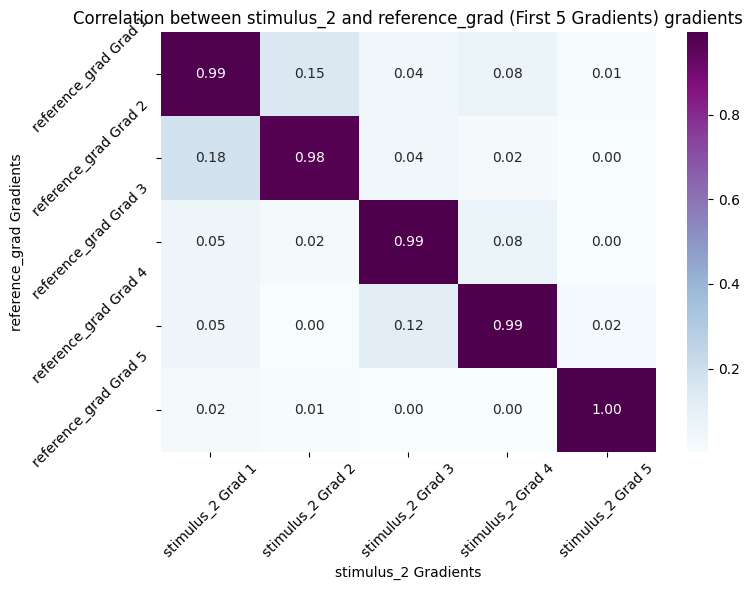

Processing comparison: remaining vs reference_grad...
Correlation Matrix for remaining vs reference_grad:
[[9.89967567e-01 1.41846351e-01 9.03868122e-03 1.27519751e-02
  1.31951946e-03]
 [2.05559208e-01 9.75617860e-01 4.33572959e-03 1.49846062e-02
  1.72929595e-02]
 [6.20085273e-03 3.54797471e-02 9.95895285e-01 4.00398561e-02
  6.15462415e-03]
 [2.55060124e-02 6.35607724e-03 7.66707094e-02 9.95551072e-01
  3.23054519e-03]
 [3.86612161e-02 9.96974799e-03 7.62498387e-04 6.13482641e-03
  9.92828371e-01]]


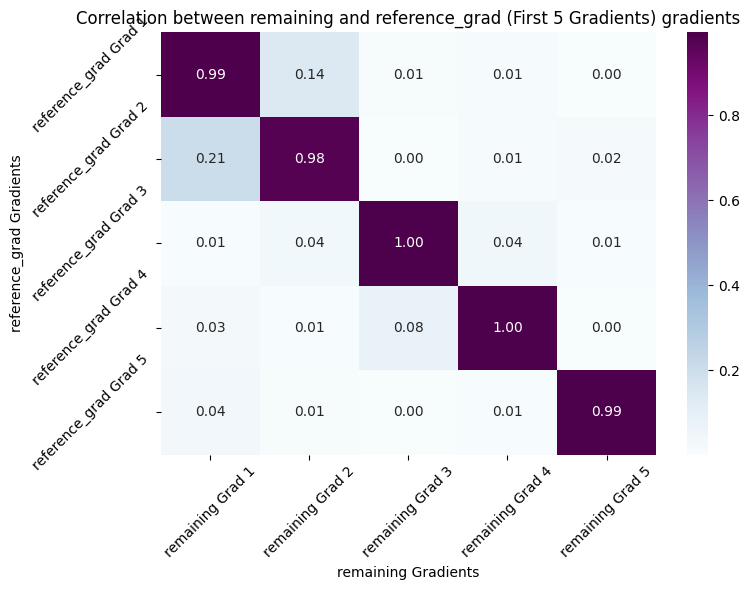

In [ ]:
# correlation matrices between unaligned gradients and whole task gradients

from neuromaps.stats import compare_images
import numpy as np
import os.path as op
import seaborn as sns
import matplotlib.pyplot as plt


# Parameters
sub = 'All'
spec = 'gradients' 
stimuli_pairs = [
    ('stimulus_1', 'reference_grad'),
    ('stimulus_2', 'reference_grad'),
    ('remaining', 'reference_grad')
]

n_gradients_to_compare = 5  # Compare only the first 5 gradients

# Loop over stimulus pairs and calculate correlations
for stim1, stim2 in stimuli_pairs:
    print(f"Processing comparison: {stim1} vs {stim2}...")
    
    # File paths to the gradient files
    grad1_file = op.join(bids_folder_matrices, 'derivatives', 'gradients', f'sub-{sub}', f'stimulus_{stim1}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stim1}.npy')
    grad2_file = op.join(bids_folder_subjects,'derivatives', 'gradients','sub-All/sub-All_gradients_N-10.npy')
    
    # Load the gradients
    grad1 = np.load(grad1_file)[:n_gradients_to_compare]  # Load first 5 gradients
    grad2 = np.load(grad2_file)[:n_gradients_to_compare]  # Load first 5 gradients

    # Initialize correlation matrix for this pair
    correlation_matrix = np.zeros((n_gradients_to_compare, n_gradients_to_compare))
    
    # Compute correlations between gradients
    for i in range(n_gradients_to_compare):
        for j in range(n_gradients_to_compare):
            corrcoef = compare_images(grad1[i], grad2[j], metric='pearsonr')
            correlation_matrix[i, j] = np.abs(corrcoef)
    
    # Print the correlation matrix
    print(f"Correlation Matrix for {stim1} vs {stim2}:")
    print(correlation_matrix)
    
    # Plot the correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="BuPu",
                xticklabels=[f'{stim1} Grad {i+1}' for i in range(n_gradients_to_compare)],
                yticklabels=[f'{stim2} Grad {i+1}' for i in range(n_gradients_to_compare)])
    plt.title(f"Correlation between {stim1} and {stim2} (First {n_gradients_to_compare} Gradients) {spec}")
    plt.xlabel(f"{stim1} Gradients")
    plt.ylabel(f"{stim2} Gradients")
    
    # Rotate the x-axis labels
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [2]:
# two-sample t-tests between network positions of stim 2 and remaining on the first gradient (because auditory network has this shift)

import numpy as np
import os
import os.path as op
import pandas as pd

sub = 'All'
stimuli_types = ['stimulus_1', 'stimulus_2', 'remaining']
spec = 'gradients'  # 'g-aligned'

# Directory to save the DataFrames
output_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients')

for stimulus in stimuli_types:
    print(f'Processing {stimulus}...')
    
    try:
        # Load the combined gradient matrix for the current stimulus
        gradients = np.load(op.join(bids_folder_matrices, 'derivatives', 'gradients', 
                                     f'sub-{sub}', f'stimulus_{stimulus}', 
                                     f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stimulus}.npy'))

        # Extract the first two rows (Gradient 1 and Gradient 2)
        grad1 = gradients[0, :]  # First row: Gradient 1
        #grad2 = gradients[1, :]  # Second row: Gradient 2

        # Create a DataFrame
        df = pd.DataFrame({
            'Gradient 1': grad1,
            #'Gradient 2': grad2,
            'ca_network': caNets_fsav5_mapping  # Map network indices to vertices
        })

        # Map network names to the ca_network column
        df['ca_network_name'] = df['ca_network'].map(CAatlas_names['Network Name'])

        # Save the DataFrame to a CSV file
        output_file = op.join(output_dir, f'{stimulus}_dataframe.csv')
        df.to_csv(output_file, index=False)
        print(f'Saved DataFrame for {stimulus} to {output_file}')

    except Exception as e:
        print(f'Failed to process {stimulus}: {e}')

NameError: name 'bids_folder_matrices' is not defined

In [62]:
# data frame of reference gradient

import pandas as pd
import numpy as np
import os.path as op

# Load the gradient data from grad2_file
grad_ref = op.join(bids_folder_subjects, 'derivatives', 'gradients', 'sub-All/sub-All_gradients_N-10.npy')
gradients = np.load(grad_ref)

# Extract the first two rows (Gradient 1 and Gradient 2)
grad1 = gradients[0, :]  # First row: Gradient 1
#grad2 = gradients[1, :]  # Second row: Gradient 2

# Create a DataFrame
df_whole_task = pd.DataFrame({
    'Gradient 1': grad1,
    #'Gradient 2': grad2,
    'ca_network': caNets_fsav5_mapping  # Map network indices to vertices
})

# Map network names to the ca_network column
df_whole_task['ca_network_name'] = df_whole_task['ca_network'].map(CAatlas_names['Network Name'])

# Save the DataFrame to a CSV file
output_file = op.join(bids_folder_subjects, 'derivatives', 'gradients', 'whole_task_dataframe.csv')
df_whole_task.to_csv(output_file, index=False)
print(f'Reference DataFrame saved to {output_file}')

Reference DataFrame saved to /mnt_03/ds-dnumrisk/derivatives/gradients/whole_task_dataframe.csv


In [ ]:
import pandas as pd
import os.path as op

# Path to the saved DataFrame
dataframe_path = op.join(bids_folder_matrices, 'derivatives', 'gradients', 'stimulus_2_dataframe.csv')

# Load the DataFrame
df = pd.read_csv(dataframe_path)

df #[df['ca_network_name'] == 'Default']['Gradient 1']

# Get the unique ca_network_name labels
unique_networks = df['ca_network_name'].unique()

# Display the unique network labels
print(unique_networks)

df.iloc[20123]

['Somatomotor' 'Visual2' 'Cingulo-Opercular' 'Frontoparietal' 'Visual1'
 nan 'Language' 'Ventral-Multimodal' 'Dorsal-attention' 'Default'
 'Auditory' 'Posterior-Multimodal' 'Orbito-Affective']


Gradient 1                      NaN
ca_network                       12
ca_network_name    Orbito-Affective
Name: 20123, dtype: object

In [81]:
df[df['ca_network_name'] == 'Default']

,Gradient 1,ca_network,ca_network_name
22,-6.354947,9,Default
25,-11.490202,9,Default
30,-6.413135,9,Default
37,-11.143966,9,Default
39,-11.217225,9,Default
...,...,...,...
20476,-11.047618,9,Default
20477,-10.835591,9,Default
20478,-10.522160,9,Default
20479,-11.050985,9,Default


In [1]:
print(stim2_df[stim2_df['ca_network_name'].isna()])
print(remaining_df[remaining_df['ca_network_name'].isna()])

NameError: name 'stim2_df' is not defined

In [ ]:
# t-test to compare network positions between stimulus_2 and remaining

import pandas as pd
from scipy.stats import ttest_ind
import os.path as op


# Load the saved DataFrames for stimulus_2 and remaining
stim2_df = pd.read_csv(op.join(bids_folder_matrices, 'derivatives', 'gradients', 'stimulus_2_dataframe.csv'))
remaining_df = pd.read_csv(op.join(bids_folder_matrices, 'derivatives', 'gradients', 'remaining_dataframe.csv'))

# Initialize a dictionary to store t-test results
t_test_results = {}

# Initialize a list to document rows with NaN values
nan_rows_log = []

# Perform two-sample t-tests for each network
for network in stim2_df['ca_network_name'].unique():
    # Filter data for the current network and convert to DataFrame
    stim2_values = stim2_df[stim2_df['ca_network_name'] == network][['Gradient 1']]
    remaining_values = remaining_df[remaining_df['ca_network_name'] == network][['Gradient 1']]
    
    # Identify rows with NaN values in either DataFrame
    stim2_nan_rows = stim2_values[stim2_values.isna().any(axis=1)].index.tolist()
    remaining_nan_rows = remaining_values[remaining_values.isna().any(axis=1)].index.tolist()
    
    # Log rows with NaN values
    if stim2_nan_rows:
        nan_rows_log.append({'network': network, 'dataframe': 'stimulus_2', 'rows': stim2_nan_rows})
    if remaining_nan_rows:
        nan_rows_log.append({'network': network, 'dataframe': 'remaining', 'rows': remaining_nan_rows})

    # Drop rows with NaN values
    stim2_values = stim2_values.dropna()
    remaining_values = remaining_values.dropna()

    # Perform the t-test if both groups have sufficient data
    if len(stim2_values) > 1 and len(remaining_values) > 1:
        t_stat, p_value = ttest_ind(stim2_values['Gradient 1'], remaining_values['Gradient 1'], equal_var=False)
    else:
        t_stat, p_value = float('nan'), float('nan')

    # Perform a two-sample t-test
    t_stat, p_value = ttest_ind(stim2_values, remaining_values, equal_var=False)  # Welch's t-test
    
    # Store the results
    t_test_results[network] = {'t_stat': t_stat, 'p_value': p_value}

# Convert results to a DataFrame for easier visualization
t_test_results_df = pd.DataFrame.from_dict(t_test_results, orient='index')
t_test_results_df.index.name = 'Network'
t_test_results_df.reset_index(inplace=True)

# Add a column to indicate significance (e.g., p < 0.05)
t_test_results_df['Significant'] = t_test_results_df['p_value'] < 0.05

# Print the results
print(t_test_results_df)

# Save the results to a CSV file
output_file = op.join(bids_folder_matrices, 'derivatives', 'gradients', 't_test_results_stim_2_remaining.csv')
t_test_results_df.to_csv(output_file, index=False)
print(f'T-test results saved to {output_file}')

# Save the log of NaN rows to a CSV file
nan_log_file = op.join(bids_folder_matrices, 'derivatives', 'gradients', 'nan_rows_log.csv')
pd.DataFrame(nan_rows_log).to_csv(nan_log_file, index=False)
print(f'NaN rows log saved to {nan_log_file}')

                 Network                 t_stat                    p_value  \
0            Somatomotor    [-14.6780246721742]    [5.651518025519688e-48]   
1                Visual2    [3.399144286830094]    [0.0006821643121564015]   
2      Cingulo-Opercular   [-7.369918216277958]   [1.9462422446772205e-13]   
3         Frontoparietal    [3.663633343035666]   [0.00025116178539988767]   
4                Visual1   [4.7505628149251375]    [2.242960095245842e-06]   
5                    NaN                  [nan]                      [nan]   
6               Language  [-2.6427704717030918]     [0.008283658888226263]   
7     Ventral-Multimodal   [13.918321931604716]    [8.589733500690518e-38]   
8       Dorsal-attention   [0.7819921904051553]       [0.4342912943568813]   
9                Default    [3.972313181297888]    [7.191756588264087e-05]   
10              Auditory   [-27.10952894445414]  [5.1076523665697346e-123]   
11  Posterior-Multimodal   [-1.698436796789844]      [0.08994683

In [23]:
# visualize t-test results in a nice table

import pandas as pd

# Load the CSV file
csv_path = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients/t_test_results.csv'
df = pd.read_csv(csv_path)

# Drop the unwanted columns
df_filtered = df.drop(columns=['t_stat', 'Significant'])

# Display the filtered table
print(df_filtered)


                 Network            p_value
0            Somatomotor   [5.65151803e-48]
1                Visual2       [0.00068216]
2      Cingulo-Opercular   [1.94624224e-13]
3         Frontoparietal       [0.00025116]
4                Visual1    [2.2429601e-06]
5                    NaN              [nan]
6               Language       [0.00828366]
7     Ventral-Multimodal    [8.5897335e-38]
8       Dorsal-attention       [0.43429129]
9                Default   [7.19175659e-05]
10              Auditory  [5.10765237e-123]
11  Posterior-Multimodal       [0.08994683]
12      Orbito-Affective       [0.52722938]


In [82]:
# t-test to compare network positions between inverted stimulus_1 and remaining

import pandas as pd
from scipy.stats import ttest_ind
import os.path as op


# Load the saved DataFrames for stimulus_1 and remaining
stim1_df = pd.read_csv(op.join(bids_folder_matrices, 'derivatives', 'gradients', 'stimulus_1_dataframe.csv'))
remaining_df = pd.read_csv(op.join(bids_folder_matrices, 'derivatives', 'gradients', 'remaining_dataframe.csv'))

# Invert the gradient values of stimulus_1
stim1_df['Gradient 1'] = -stim1_df['Gradient 1']

# Initialize a dictionary to store t-test results
t_test_results = {}

# Initialize a list to document rows with NaN values
nan_rows_log = []

# Perform two-sample t-tests for each network
for network in stim1_df['ca_network_name'].unique():
    # Filter data for the current network and convert to DataFrame
    stim1_values = stim1_df[stim1_df['ca_network_name'] == network][['Gradient 1']]
    remaining_values = remaining_df[remaining_df['ca_network_name'] == network][['Gradient 1']]
    
    # Identify rows with NaN values in either DataFrame
    stim1_nan_rows = stim1_values[stim1_values.isna().any(axis=1)].index.tolist()
    remaining_nan_rows = remaining_values[remaining_values.isna().any(axis=1)].index.tolist()
    
    # Log rows with NaN values
    if stim1_nan_rows:
        nan_rows_log.append({'network': network, 'dataframe': 'stimulus_2', 'rows': stim1_nan_rows})
    if remaining_nan_rows:
        nan_rows_log.append({'network': network, 'dataframe': 'remaining', 'rows': remaining_nan_rows})

    # Drop rows with NaN values
    stim1_values = stim1_values.dropna()
    remaining_values = remaining_values.dropna()

    # Perform the t-test if both groups have sufficient data
    if len(stim1_values) > 1 and len(remaining_values) > 1:
        t_stat, p_value = ttest_ind(stim1_values['Gradient 1'], remaining_values['Gradient 1'], equal_var=False)
    else:
        t_stat, p_value = float('nan'), float('nan')

    # Perform a two-sample t-test
    t_stat, p_value = ttest_ind(stim1_values, remaining_values, equal_var=False)  # Welch's t-test
    
    # Store the results
    t_test_results[network] = {'t_stat': t_stat, 'p_value': p_value}

# Convert results to a DataFrame for easier visualization
t_test_results_df = pd.DataFrame.from_dict(t_test_results, orient='index')
t_test_results_df.index.name = 'Network'
t_test_results_df.reset_index(inplace=True)

# Add a column to indicate significance (e.g., p < 0.05)
t_test_results_df['Significant'] = t_test_results_df['p_value'] < 0.05

# Print the results
print(t_test_results_df)

# Save the results to a CSV file
output_file = op.join(bids_folder_matrices, 'derivatives', 'gradients', 't_test_results_stim_1_remaining.csv')
t_test_results_df.to_csv(output_file, index=False)
print(f'T-test results saved to {output_file}')

# Save the log of NaN rows to a CSV file
nan_log_file = op.join(bids_folder_matrices, 'derivatives', 'gradients', 'nan_rows_log.csv')
pd.DataFrame(nan_rows_log).to_csv(nan_log_file, index=False)
print(f'NaN rows log saved to {nan_log_file}')

                 Network                 t_stat                    p_value  \
0            Somatomotor   [-20.25124108912399]   [3.7155422881575765e-88]   
1                Visual2  [-12.661927746792017]   [4.2550565086364805e-36]   
2      Cingulo-Opercular   [-6.775296830022632]     [1.36722812195666e-11]   
3         Frontoparietal    [4.224476029231759]   [2.4413646606882564e-05]   
4                Visual1  [-10.003866239384323]    [8.489215043675711e-23]   
5                    NaN                  [nan]                      [nan]   
6               Language   [2.6962671456383123]     [0.007072357354980046]   
7     Ventral-Multimodal     [67.4104633433276]  [1.1213774471508154e-223]   
8       Dorsal-attention   [-4.203099559916546]   [2.7232251231834055e-05]   
9                Default    [28.28956854076632]  [1.5791076511680523e-165]   
10              Auditory  [-0.5725181150870587]       [0.5670953133816362]   
11  Posterior-Multimodal   [-2.491145661350111]     [0.013002387

In [67]:
stim2_values

82       -6.777467
202      -2.162565
323     -11.360747
428     -11.212299
598            NaN
           ...    
20117   -11.516625
20120   -11.364997
20121   -10.463417
20122    -9.905747
20123          NaN
Name: Gradient 1, Length: 252, dtype: float64

In [49]:
stim1_df = pd.read_csv(op.join(bids_folder_matrices, 'derivatives', 'gradients', 'stimulus_1_dataframe.csv'))


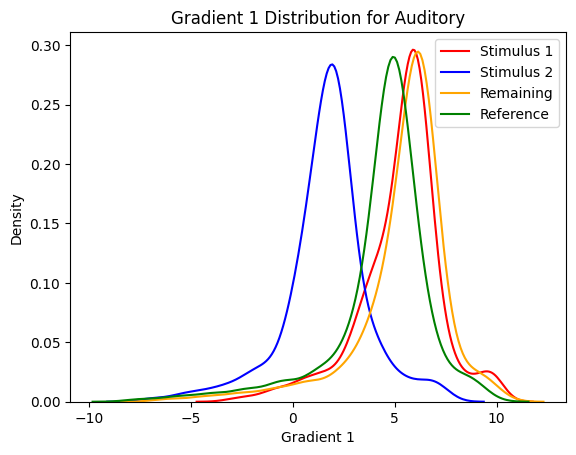

In [65]:
net_name = 'Auditory'
sns.kdeplot(-stim1_df[stim1_df['ca_network_name'] == net_name]['Gradient 1'], label='Stimulus 1', color='red')
sns.kdeplot(stim2_df[stim2_df['ca_network_name'] == net_name]['Gradient 1'], label='Stimulus 2', color='blue')
sns.kdeplot(remaining_df[remaining_df['ca_network_name'] == net_name]['Gradient 1'], label='Remaining', color='orange')
sns.kdeplot(df_whole_task[df_whole_task['ca_network_name'] == net_name]['Gradient 1'], label='Reference', color='green')
plt.title(f'Gradient 1 Distribution for {net_name}')
plt.legend()

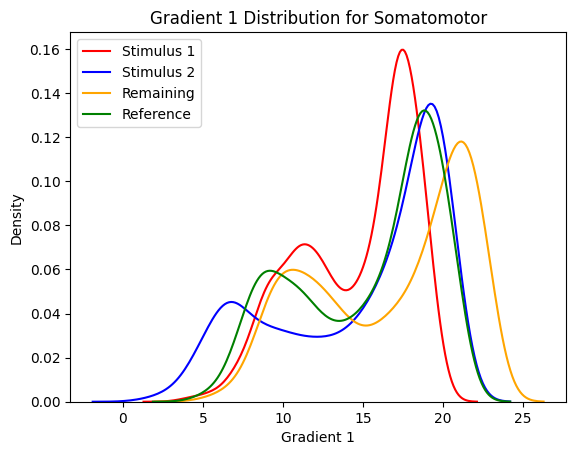

In [63]:
net_name = 'Somatomotor'
sns.kdeplot(-stim1_df[stim1_df['ca_network_name'] == net_name]['Gradient 1'], label='Stimulus 1', color='red')

sns.kdeplot(stim2_df[stim2_df['ca_network_name'] == net_name]['Gradient 1'], label='Stimulus 2', color='blue')
sns.kdeplot(remaining_df[remaining_df['ca_network_name'] == net_name]['Gradient 1'], label='Remaining', color='orange')
sns.kdeplot(df_whole_task[df_whole_task['ca_network_name'] == net_name]['Gradient 1'], label='Reference', color='green')
plt.title(f'Gradient 1 Distribution for {net_name}')
plt.legend()